In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
orders = 'https://raw.githubusercontent.com/zzzer0-wav/Shop-Sphere-Analysis/refs/heads/main/data/shopsphere_orders.csv'
customers = 'https://raw.githubusercontent.com/zzzer0-wav/Shop-Sphere-Analysis/refs/heads/main/data/shopsphere_customers.csv'
customers_origin = pd.read_csv(customers)
customers = customers_origin.copy()
orders_origin = pd.read_csv(orders)
orders = orders_origin.copy()

In [3]:
spend_a = orders[orders['ab_variant']=='A']['net_amount']
spend_b = orders[orders['ab_variant']=='B']['net_amount']

print(f'Group A: {round(spend_a.mean(), 2)} $')
print(f'Group B: {round(spend_b.mean(), 2)} $')

t_stats, p_value = stats.ttest_ind(spend_a, spend_b)

if p_value < 0.05:
    print(f'Різниця статистично значуща, B - краща, p-value: {p_value}')
else:
    print(f'Різниця статистично не значуща, B випадково має кращий результат, p-value: {p_value}')


Group A: 281.73 $
Group B: 287.27 $
Різниця статистично не значуща, B випадково має кращий результат, p-value: 0.5129229535686819


In [4]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

In [5]:
orders.head()

,order_id,customer_id,order_date,order_year,order_month,device,channel,discount_pct,gross_amount,discount_amount,net_amount,free_shipping,ab_variant,is_returned
0,200001,10001,2024-05-14,2024,5,Mobile,Organic,5,93.76,4.69,89.07,1,NaN,0
1,200002,10001,2024-08-08,2024,8,Desktop,Social Ads,5,260.38,13.02,239.94,1,B,0
2,200003,10001,2024-11-28,2024,11,Desktop,Influencer,10,1017.84,101.78,916.06,1,A,0
3,200004,10001,2024-11-05,2024,11,Mobile,Influencer,0,686.36,0.00,665.77,1,B,1
4,200005,10001,2024-08-14,2024,8,Mobile,Referral,0,764.44,0.00,741.51,1,B,0


In [6]:
orders['days_since_signup'] = (orders['order_date'] - customers['signup_date']).dt.days
orders['customer_type'] = orders['days_since_signup'].apply(lambda x: 'new' if x<=60 else 'returning')
orders

,order_id,customer_id,order_date,order_year,order_month,device,channel,discount_pct,gross_amount,discount_amount,net_amount,free_shipping,ab_variant,is_returned,days_since_signup,customer_type
0,200001,10001,2024-05-14,2024,5,Mobile,Organic,5,93.76,4.69,89.07,1,NaN,0,523.0,returning
1,200002,10001,2024-08-08,2024,8,Desktop,Social Ads,5,260.38,13.02,239.94,1,B,0,884.0,returning
2,200003,10001,2024-11-28,2024,11,Desktop,Influencer,10,1017.84,101.78,916.06,1,A,0,73.0,returning
3,200004,10001,2024-11-05,2024,11,Mobile,Influencer,0,686.36,0.00,665.77,1,B,1,239.0,returning
4,200005,10001,2024-08-14,2024,8,Mobile,Referral,0,764.44,0.00,741.51,1,B,0,438.0,returning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12269,212270,12999,2024-10-18,2024,10,Mobile,Paid Search,0,939.51,0.00,911.32,1,B,1,NaN,returning
12270,212271,12999,2024-11-11,2024,11,Desktop,Influencer,10,94.24,9.42,84.82,1,A,0,NaN,returning
12271,212272,12999,2023-11-10,2023,11,Mobile,Referral,5,17.26,0.86,16.40,0,NaN,0,NaN,returning
12272,212273,13000,2023-09-20,2023,9,Desktop,Influencer,0,57.63,0.00,57.63,1,NaN,0,NaN,returning


In [7]:
a_new = orders[(orders['ab_variant']=='A') & (orders['customer_type']=='new')]['net_amount']
b_new = orders[(orders['ab_variant']=='B') & (orders['customer_type']=='new')]['net_amount']
a_old = orders[(orders['ab_variant']=='A') & (orders['customer_type']=='returning')]['net_amount']
b_old = orders[(orders['ab_variant']=='B') & (orders['customer_type']=='returning')]['net_amount']

avg_check_a_new = a_new.mean()
avg_check_b_new = b_new.mean()
avg_check_a_returning = a_old.mean()
avg_check_b_returning = b_old.mean()
print('A_new:',avg_check_a_new)
print('B_new:',avg_check_b_new)
print('A_old:',avg_check_a_returning)
print('B_old:',avg_check_b_returning)
print()

t, p = stats.ttest_ind(a_new, b_new)
print(f't = {t}, p = {p}')
print()
t, p = stats.ttest_ind(a_old, b_old)
print(f't = {t}, p = {p}')

A_new: 263.49644230769235
B_new: 283.0761764705882
A_old: 282.25786972323175
B_old: 287.3903555431131

t = -0.360267178912254, p = 0.7190200694373352

t = -0.5985787350022425, p = 0.5494728097152166


In [8]:
avg_new = (avg_check_a_new + avg_check_b_new) / 2
avg_new

np.float64(273.2863093891403)

In [9]:
avg_old = (avg_check_a_returning + avg_check_b_returning) / 2
avg_old

np.float64(284.82411263317243)

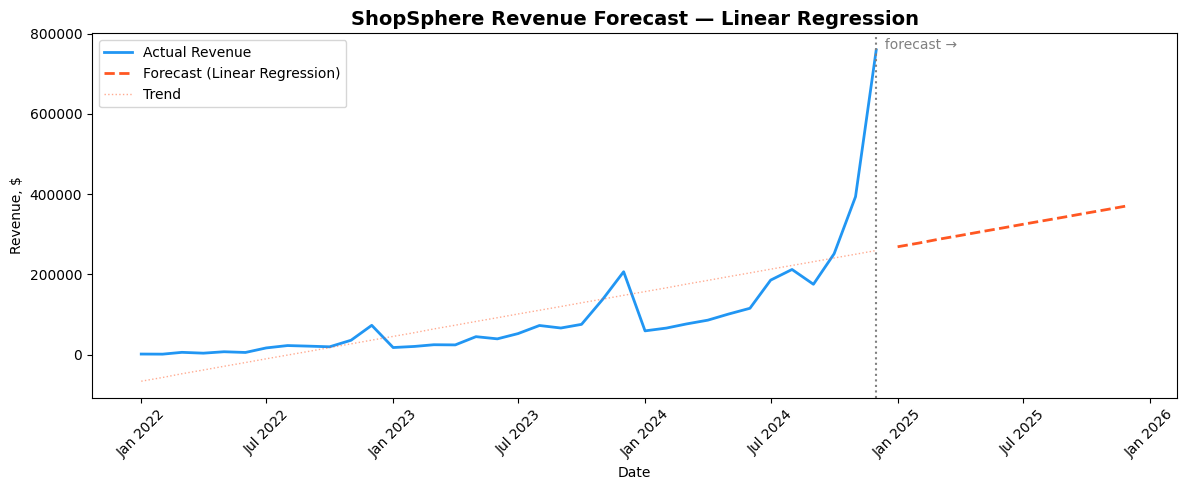

In [10]:
from sklearn.linear_model import LinearRegression


monthly = orders.groupby(orders['order_date'].dt.to_period('M'))['net_amount'].sum().reset_index()
monthly.columns = ['date', 'revenue']
monthly['date'] = monthly['date'].dt.to_timestamp()


monthly['month_index'] = range(len(monthly))


X = monthly[['month_index']]
y = monthly['revenue']
model = LinearRegression()
model.fit(X, y)


future_index = range(len(monthly), len(monthly) + 12)
future_dates = pd.date_range(start=monthly['date'].max(), periods=13, freq='MS')[1:]
predictions = model.predict(pd.DataFrame({'month_index': future_index}))


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly['date'], monthly['revenue'],
        label='Actual Revenue', color='#2196F3', linewidth=2)

ax.plot(future_dates, predictions,
        label='Forecast (Linear Regression)', color='#FF5722', linewidth=2, linestyle='--')

ax.plot(monthly['date'], model.predict(X),
        color='#FF5722', linewidth=1, linestyle=':', alpha=0.5, label='Trend')

ax.axvline(x=monthly['date'].max(), color='gray', linestyle=':', linewidth=1.5)
ax.text(monthly['date'].max(), ax.get_ylim()[1] * 0.95, '  forecast →', color='gray')

ax.set_title('ShopSphere Revenue Forecast — Linear Regression', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue, $')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


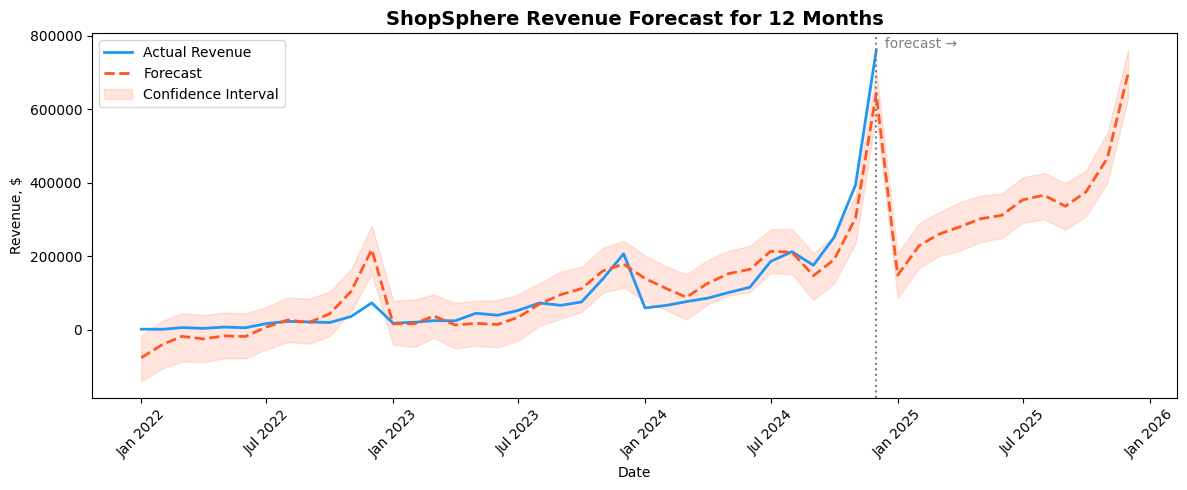

In [11]:
monthly = orders.groupby(orders['order_date'].dt.to_period('M'))['net_amount'].sum().reset_index()
monthly.columns = ['ds', 'y']
monthly['ds'] = monthly['ds'].dt.to_timestamp()


model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model.fit(monthly)


future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly['ds'], monthly['y'],
        label='Actual Revenue', color='#2196F3', linewidth=2)

ax.plot(forecast['ds'], forecast['yhat'],
        label='Forecast', color='#FF5722', linewidth=2, linestyle='--')

ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.15, color='#FF5722', label='Confidence Interval')


ax.axvline(x=monthly['ds'].max(), color='gray', linestyle=':', linewidth=1.5)
ax.text(monthly['ds'].max(), ax.get_ylim()[1] * 0.95, '  forecast →', color='gray')

ax.set_title('ShopSphere Revenue Forecast for 12 Months', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue, $')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
ltv_per_customer = orders.groupby('customer_id')['net_amount'].sum().reset_index()
ltv_per_customer.columns = ['customer_id', 'total_ltv']


ltv_per_customer = ltv_per_customer.merge(
    customers[['customer_id', 'acquisition_channel']], on='customer_id'
)


ltv_by_channel = ltv_per_customer.groupby('acquisition_channel')['total_ltv'].mean().round(2)
print(ltv_by_channel.sort_values(ascending=False))

acquisition_channel
Influencer     1985.73
Referral       1791.82
Organic        1316.13
Email          1074.46
Social Ads      822.09
Paid Search     648.10
Name: total_ltv, dtype: float64
